# Exercício Prático 2
### Eduardo Santos Birchal
### Matrícula: 2024023970

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna
import time
from sklearn.tree import DecisionTreeClassifier

# Árvore de Decisão

In [42]:
df_secao1 = pd.read_csv('dados/secao1.csv')

x = df_secao1[['x1', 'x2']].values
y = df_secao1['y'].values

## Definições de função

In [43]:
def calcular_gini(y):
    # calcula a impureza de gini
    n = len(y)
    if n == 0:
        return 0.0
    p1 = np.sum(y == 1) / n
    p0 = 1.0 - p1
    return 1.0 - (p0**2 + p1**2)

def calcular_ganho(y, y_esq, y_dir):
    # calcula o ganho de informacao de gini
    gini_pai = calcular_gini(y)
    n = len(y)
    n_esq = len(y_esq)
    n_dir = len(y_dir)
    
    if n == 0:
        return 0.0
        
    gini_esq = calcular_gini(y_esq)
    gini_dir = calcular_gini(y_dir)
    
    ganho = gini_pai - ((n_esq / n) * gini_esq + (n_dir / n) * gini_dir)
    return ganho

In [44]:
def encontrar_melhor_split(x, y, min_samples_leaf=1):
    # encontra o melhor corte para o nó atual
    melhor_ganho = -1.0
    melhor_coluna = None
    melhor_limiar = None
    melhor_esq = None
    melhor_dir = None
    
    n_amostras, n_colunas = x.shape
    
    for j in range(n_colunas):
        valores = x[:, j]
        valores_unicos = np.unique(valores)
        
        # verifica se tem pelo menos dois valores unicos para testar cortes
        if len(valores_unicos) < 2:
            continue
            
        limiares = (valores_unicos[:-1] + valores_unicos[1:]) / 2.0
        
        for t in limiares:
            idx_esq = valores < t
            idx_dir = ~idx_esq
            
            # verifica o numero minimo de amostras nas folhas
            if np.sum(idx_esq) < min_samples_leaf or np.sum(idx_dir) < min_samples_leaf:
                continue
                
            y_esq = y[idx_esq]
            y_dir = y[idx_dir]
            
            ganho = calcular_ganho(y, y_esq, y_dir)
            
            if ganho > melhor_ganho:
                melhor_ganho = ganho
                melhor_coluna = j
                melhor_limiar = t
                melhor_esq = idx_esq
                melhor_dir = idx_dir
                
    return melhor_coluna, melhor_limiar, melhor_ganho, melhor_esq, melhor_dir

In [45]:
def divisao_estratificada(x, y, test_size=0.3, seed=None):
    # realiza a divisao de treino e teste mantendo a proporcao de classes
    if seed is not None:
        np.random.seed(seed)
        
    classes = np.unique(y)
    idx_treino = []
    idx_teste = []
    
    for c in classes:
        idx_c = np.where(y == c)[0]
        np.random.shuffle(idx_c)
        n_teste = int(len(idx_c) * test_size)
        idx_teste.extend(idx_c[:n_teste])
        idx_treino.extend(idx_c[n_teste:])
        
    idx_treino = np.array(idx_treino)
    idx_teste = np.array(idx_teste)
    
    # embaralhar para misturar as amostras de diferentes classes
    np.random.shuffle(idx_treino)
    np.random.shuffle(idx_teste)
    
    return x[idx_treino], x[idx_teste], y[idx_treino], y[idx_teste]

In [46]:
class Node:
    def __init__(self, predicao, probabilidade):
        self.predicao = predicao
        self.probabilidade = probabilidade
        self.coluna = None
        self.limiar = None
        self.esq = None
        self.dir = None

class DecisionTree:
    def __init__(self, max_depth=None, min_samples_leaf=1, min_gain=0.0):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.min_gain = min_gain
        self.raiz = None
        
    def fit(self, x, y):
        self.raiz = self._crescer_arvore(x, y, 0)
        
    def _crescer_arvore(self, x, y, profundidade):
        n_amostras = len(y)
        contagem_1 = np.sum(y == 1)
        prob_1 = contagem_1 / n_amostras if n_amostras > 0 else 0.0
        predicao = 1 if prob_1 >= 0.5 else 0
        
        no = Node(predicao, prob_1)
        
        # criterios de parada basicos
        if (self.max_depth is not None and profundidade >= self.max_depth) or \
           len(np.unique(y)) <= 1:
            return no
            
        coluna, limiar, ganho, idx_esq, idx_dir = encontrar_melhor_split(
            x, y, min_samples_leaf=self.min_samples_leaf
        )
        
        # nenhum split superou o ganho minimo estritamente positivo
        if coluna is None or ganho <= self.min_gain:
            return no
            
        no.coluna = coluna
        no.limiar = limiar
        no.esq = self._crescer_arvore(x[idx_esq], y[idx_esq], profundidade + 1)
        no.dir = self._crescer_arvore(x[idx_dir], y[idx_dir], profundidade + 1)
        
        return no
        
    def predict_proba(self, x):
        # prediz as probabilidades para novas amostras
        probas = np.zeros(len(x))
        for i in range(len(x)):
            no_atual = self.raiz
            while no_atual.esq is not None and no_atual.dir is not None:
                if x[i, no_atual.coluna] < no_atual.limiar:
                    no_atual = no_atual.esq
                else:
                    no_atual = no_atual.dir
            probas[i] = no_atual.probabilidade
        return probas
        
    def predict(self, x):
        # prediz as classes com base no limiar de 0.5
        probas = self.predict_proba(x)
        return (probas >= 0.5).astype(int)

## Busca pelo melhor split

In [47]:
coluna, limiar, ganho, idx_esq, idx_dir = encontrar_melhor_split(x, y, min_samples_leaf=1)

print("melhor split inicial:")

nome_coluna = 'x1' if coluna == 0 else 'x2'
y_esq = y[idx_esq]
y_dir = y[idx_dir]

esq_0, esq_1 = np.sum(y_esq == 0), np.sum(y_esq == 1)
dir_0, dir_1 = np.sum(y_dir == 0), np.sum(y_dir == 1)

print(f"variavel: {nome_coluna}")
print(f"limiar: {limiar:.4f}")
print(f"ganho: {ganho:.4f}")
print("\ntabela de contagem nos filhos:")
print("          | classe 0 | classe 1")
print("-------------------------------")
print(f"filho esq | {esq_0:8d} | {esq_1:8d}")
print(f"filho dir | {dir_0:8d} | {dir_1:8d}\n")

melhor split inicial:
variavel: x1
limiar: 0.6228
ganho: 0.1195

tabela de contagem nos filhos:
          | classe 0 | classe 1
-------------------------------
filho esq |      248 |       59
filho dir |       59 |      134



## Visualização das fronteiras

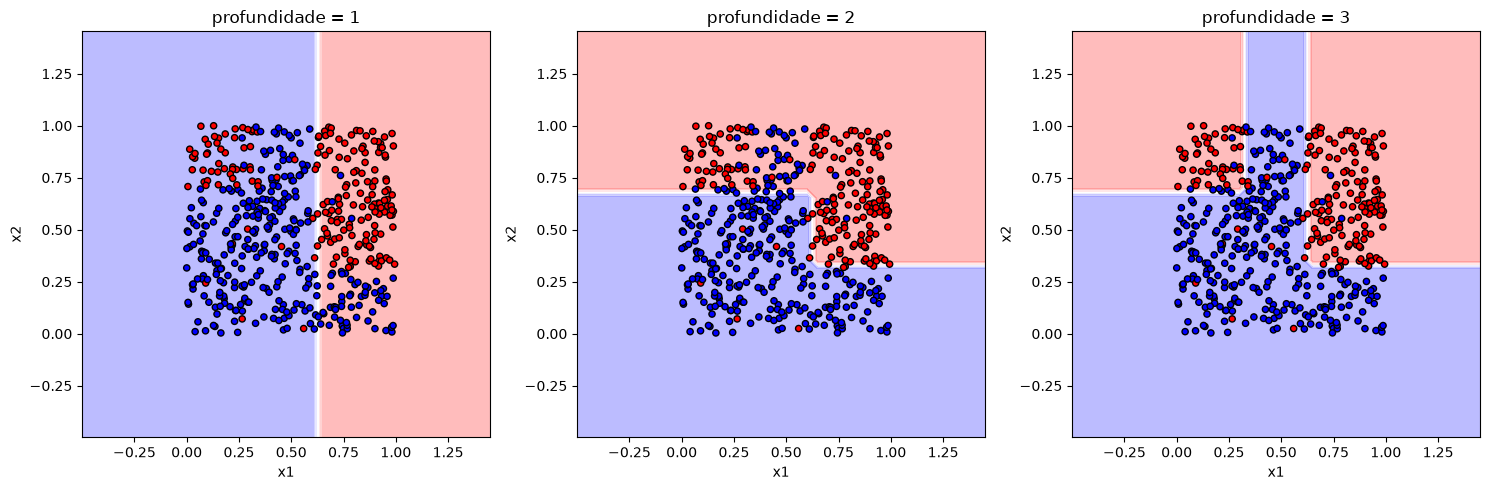

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
profundidades = [1, 2, 3]

margem = 0.5
x1_min, x1_max = x[:, 0].min() - margem, x[:, 0].max() + margem
x2_min, x2_max = x[:, 1].min() - margem, x[:, 1].max() + margem
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.05),
                        np.arange(x2_min, x2_max, 0.05))
malha = np.c_[xx1.ravel(), xx2.ravel()]

for i, p in enumerate(profundidades):
    arvore = DecisionTree(max_depth=p, min_samples_leaf=5, min_gain=0.0)
    arvore.fit(x, y)
    
    z = arvore.predict(malha)
    z = z.reshape(xx1.shape)
    
    ax = axes[i]
    ax.contourf(xx1, xx2, z, alpha=0.3, cmap='bwr')
    ax.scatter(x[:, 0], x[:, 1], c=y, cmap='bwr', edgecolor='k', s=20)
    ax.set_title(f'profundidade = {p}')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    
plt.tight_layout()
plt.savefig('fronteiras_decisao.png')
plt.show()

## Avaliação do modelo

In [49]:
x_treino, x_teste, y_treino, y_teste = divisao_estratificada(x, y, test_size=0.3, seed=42)

arvore = DecisionTree(max_depth=3, min_samples_leaf=5, min_gain=0.0)
arvore.fit(x_treino, y_treino)

y_pred = arvore.predict(x_teste)

vp = np.sum((y_teste == 1) & (y_pred == 1))
vn = np.sum((y_teste == 0) & (y_pred == 0))
fp = np.sum((y_teste == 0) & (y_pred == 1))
fn = np.sum((y_teste == 1) & (y_pred == 0))

acuracia = (vp + vn) / len(y_teste) if len(y_teste) > 0 else 0.0

print(f"acuracia no teste: {acuracia:.4f}")
print("\nmatriz de confusao:")
print("             | predito 0 | predito 1")
print("------------------------------------")
print(f"verdadeiro 0 | {vn:9d} | {fp:9d}")
print(f"verdadeiro 1 | {fn:9d} | {vp:9d}\n")

acuracia no teste: 0.9866

matriz de confusao:
             | predito 0 | predito 1
------------------------------------
verdadeiro 0 |        92 |         0
verdadeiro 1 |         2 |        55



# Tuning de hiperparâmetros

In [50]:
# desativar logs extensos do optuna para manter o terminal limpo
optuna.logging.set_verbosity(optuna.logging.WARNING)

df_tuning = pd.read_csv('dados/dados_tuning.csv')
    
preditores = ['x1', 'x2', 'x3', 'x4', 'x5']
x = df_tuning[preditores].values
y = df_tuning['y'].values

## Definições de função

In [51]:
def divisao_estratificada(x, y, test_size=0.3, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    classes = np.unique(y)
    idx_treino = []
    idx_teste = []
    
    for c in classes:
        idx_c = np.where(y == c)[0]
        np.random.shuffle(idx_c)
        n_teste = int(len(idx_c) * test_size)
        idx_teste.extend(idx_c[:n_teste])
        idx_treino.extend(idx_c[n_teste:])
        
    idx_treino = np.array(idx_treino)
    idx_teste = np.array(idx_teste)
    
    np.random.shuffle(idx_treino)
    np.random.shuffle(idx_teste)
    
    return x[idx_treino], x[idx_teste], y[idx_treino], y[idx_teste]

def kfold_estratificado_indices(y, k=4, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    classes = np.unique(y)
    folds = [[] for _ in range(k)]
    
    for c in classes:
        idx_c = np.where(y == c)[0]
        np.random.shuffle(idx_c)
        splits = np.array_split(idx_c, k)
        for i in range(k):
            folds[i].extend(splits[i])
            
    folds_indices = []
    for i in range(k):
        idx_teste = np.array(folds[i])
        idx_treino = np.hstack([folds[j] for j in range(k) if j != i])
        
        np.random.shuffle(idx_treino)
        np.random.shuffle(idx_teste)
        
        folds_indices.append((idx_treino, idx_teste))
        
    return folds_indices

def avaliar_modelo_cv(x, y, folds_indices, max_depth, min_samples_leaf, min_impurity_decrease):
    acuracias = []
    for idx_treino, idx_teste in folds_indices:
        modelo = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            min_impurity_decrease=min_impurity_decrease,
            random_state=42
        )
        x_tr, y_tr = x[idx_treino], y[idx_treino]
        x_te, y_te = x[idx_teste], y[idx_teste]
        
        modelo.fit(x_tr, y_tr)
        preds = modelo.predict(x_te)
        acc = np.mean(preds == y_te)
        acuracias.append(acc)
        
    return np.mean(acuracias)

In [52]:
def busca_em_grade(x, y, folds_indices):
    valores_d = [1, 2, 3, 4, 5, 6]
    valores_n_min = [5, 10, 20, 30, 50]
    valores_min_gain = np.linspace(0.0, 0.05, 5)
    
    melhor_acc = -1.0
    melhor_config = None
    historico = []
    resultados_agregados = []
    
    t0 = time.time()
    for d in valores_d:
        for n_min in valores_n_min:
            for min_gain in valores_min_gain:
                acc = avaliar_modelo_cv(x, y, folds_indices, d, n_min, min_gain)
                historico.append(acc)
                resultados_agregados.append((d, n_min, min_gain, acc))
                
                if acc > melhor_acc:
                    melhor_acc = acc
                    melhor_config = (d, n_min, min_gain)
                    
    tempo_total = time.time() - t0
    n_combinacoes = len(valores_d) * len(valores_n_min) * len(valores_min_gain)
    n_modelos = n_combinacoes * len(folds_indices)
    
    return melhor_config, melhor_acc, historico, n_modelos, tempo_total, resultados_agregados

def busca_aleatoria(x, y, folds_indices, n_iteracoes):
    valores_d = [1, 2, 3, 4, 5, 6]
    valores_n_min = [5, 10, 20, 30, 50]
    
    melhor_acc = -1.0
    melhor_config = None
    historico_acumulado = []
    
    t0 = time.time()
    np.random.seed(42)
    for _ in range(n_iteracoes):
        d = int(np.random.choice(valores_d))
        n_min = int(np.random.choice(valores_n_min))
        min_gain = float(np.random.uniform(0.0, 0.05))
        
        acc = avaliar_modelo_cv(x, y, folds_indices, d, n_min, min_gain)
        
        if acc > melhor_acc:
            melhor_acc = acc
            melhor_config = (d, n_min, min_gain)
            
        historico_acumulado.append(melhor_acc)
        
    tempo_total = time.time() - t0
    n_modelos = n_iteracoes * len(folds_indices)
    
    return melhor_config, melhor_acc, historico_acumulado, n_modelos, tempo_total

def busca_bayesiana(x, y, folds_indices, n_iteracoes):
    def objetivo(trial):
        d = trial.suggest_int('d', 1, 6)
        n_min = trial.suggest_categorical('n_min', [5, 10, 20, 30, 50])
        min_gain = trial.suggest_float('min_gain', 0.0, 0.05)
        
        return avaliar_modelo_cv(x, y, folds_indices, d, n_min, min_gain)

    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    
    t0 = time.time()
    study.optimize(objetivo, n_trials=n_iteracoes)
    tempo_total = time.time() - t0
    
    melhor_config = (study.best_params['d'], study.best_params['n_min'], study.best_params['min_gain'])
    melhor_acc = study.best_value
    
    historico_acumulado = []
    melhor_atual = -1.0
    for trial in study.trials:
        if trial.value > melhor_atual:
            melhor_atual = trial.value
        historico_acumulado.append(melhor_atual)
        
    n_modelos = n_iteracoes * len(folds_indices)
    
    return melhor_config, melhor_acc, historico_acumulado, n_modelos, tempo_total

In [53]:
def gerar_grafico_convergencia(historico_random, historico_optuna):
    iteracoes = range(1, len(historico_random) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(iteracoes, historico_random, label='busca aleatoria', color='blue')
    plt.plot(iteracoes, historico_optuna, label='otimizacao bayesiana', color='green')
    
    plt.plot(len(historico_random), historico_random[-1], marker='o', color='blue')
    plt.plot(len(historico_optuna), historico_optuna[-1], marker='o', color='green')
    
    plt.xlabel('iteracao')
    plt.ylabel('melhor acuracia cv acumulada')
    plt.title('convergencia das tecnicas de busca')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.savefig('grafico_convergencia.png')
    plt.show()
    plt.close()

def gerar_heatmaps(resultados_agregados):
    df = pd.DataFrame(resultados_agregados, columns=['d', 'n_min', 'min_gain', 'acc'])
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    pivot1 = df.groupby(['d', 'n_min'])['acc'].mean().unstack()
    im1 = axes[0].imshow(pivot1.values, origin='lower', aspect='auto', cmap='viridis')
    axes[0].set_xticks(np.arange(len(pivot1.columns)))
    axes[0].set_xticklabels(pivot1.columns)
    axes[0].set_yticks(np.arange(len(pivot1.index)))
    axes[0].set_yticklabels(pivot1.index)
    axes[0].set_xlabel('n_min')
    axes[0].set_ylabel('d')
    axes[0].set_title('acuracia media: d vs n_min')
    fig.colorbar(im1, ax=axes[0])
    
    pivot2 = df.groupby(['d', 'min_gain'])['acc'].mean().unstack()
    im2 = axes[1].imshow(pivot2.values, origin='lower', aspect='auto', cmap='viridis')
    labels_mg2 = [f"{v:.4f}" for v in pivot2.columns]
    axes[1].set_xticks(np.arange(len(pivot2.columns)))
    axes[1].set_xticklabels(labels_mg2)
    axes[1].set_yticks(np.arange(len(pivot2.index)))
    axes[1].set_yticklabels(pivot2.index)
    axes[1].set_xlabel('min_gain')
    axes[1].set_ylabel('d')
    axes[1].set_title('acuracia media: d vs min_gain')
    fig.colorbar(im2, ax=axes[1])
    
    pivot3 = df.groupby(['n_min', 'min_gain'])['acc'].mean().unstack()
    im3 = axes[2].imshow(pivot3.values, origin='lower', aspect='auto', cmap='viridis')
    labels_mg3 = [f"{v:.4f}" for v in pivot3.columns]
    axes[2].set_xticks(np.arange(len(pivot3.columns)))
    axes[2].set_xticklabels(labels_mg3)
    axes[2].set_yticks(np.arange(len(pivot3.index)))
    axes[2].set_yticklabels(pivot3.index)
    axes[2].set_xlabel('min_gain')
    axes[2].set_ylabel('n_min')
    axes[2].set_title('acuracia media: n_min vs min_gain')
    fig.colorbar(im3, ax=axes[2])
    
    plt.tight_layout()
    plt.savefig('grafico_heatmaps.png')
    plt.show()
    plt.close()

def calcular_matriz_confusao(y_true, y_pred):
    vp = np.sum((y_true == 1) & (y_pred == 1))
    vn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return vp, vn, fp, fn

In [54]:
def avaliacao_final_teste(x_tr, y_tr, x_te, y_te, configs, res_cv, tempos, n_modelos):
    nomes = ['grade', 'aleatoria', 'bayesiana']
    
    print(f"{'estrategia':<12} | {'tripla (d, n_min, min_gain)':<30} | {'acc cv':<8} | {'acc teste':<10} | {'ajustes':<8} | {'tempo (s)':<10}")
    print("-" * 90)
    
    matrizes = []
    
    for i, nome in enumerate(nomes):
        d, n_min, min_gain = configs[i]
        acc_cv = res_cv[i]
        tempo = tempos[i]
        n_mod = n_modelos[i]
        
        modelo = DecisionTreeClassifier(
            max_depth=d,
            min_samples_leaf=n_min,
            min_impurity_decrease=min_gain,
            random_state=42
        )
        modelo.fit(x_tr, y_tr)
        preds = modelo.predict(x_te)
        
        acc_te = np.mean(preds == y_te)
        vp, vn, fp, fn = calcular_matriz_confusao(y_te, preds)
        matrizes.append((nome, vp, vn, fp, fn))
        
        tripla_str = f"({d}, {n_min}, {min_gain:.4f})"
        print(f"{nome:<12} | {tripla_str:<30} | {acc_cv:.4f}   | {acc_te:.4f}     | {n_mod:<8} | {tempo:.4f}")
        
    print("\nmatrizes de confusao no teste:")
    for nome, vp, vn, fp, fn in matrizes:
        print(f"\n--- {nome} ---")
        print("             | predito 0 | predito 1")
        print("------------------------------------")
        print(f"verdadeiro 0 | {vn:9d} | {fp:9d}")
        print(f"verdadeiro 1 | {fn:9d} | {vp:9d}")

## Gerando as informações

In [55]:
# gerando os folds
x_tr, x_te, y_tr, y_te = divisao_estratificada(x, y, test_size=0.3, seed=42)
folds_indices = kfold_estratificado_indices(y_tr, k=4, seed=42)

In [56]:
# busca em grade
config_grade, acc_grade, hist_grade, n_mod_grade, t_grade, res_agregados = busca_em_grade(x_tr, y_tr, folds_indices)

n_iteracoes = len(hist_grade)

In [57]:
# busca aleatoria
config_rand, acc_rand, hist_rand, n_mod_rand, t_rand = busca_aleatoria(x_tr, y_tr, folds_indices, n_iteracoes)

In [58]:
# otimizacao bayesiana
config_bay, acc_bay, hist_bay, n_mod_bay, t_bay = busca_bayesiana(x_tr, y_tr, folds_indices, n_iteracoes)

## Avaliação

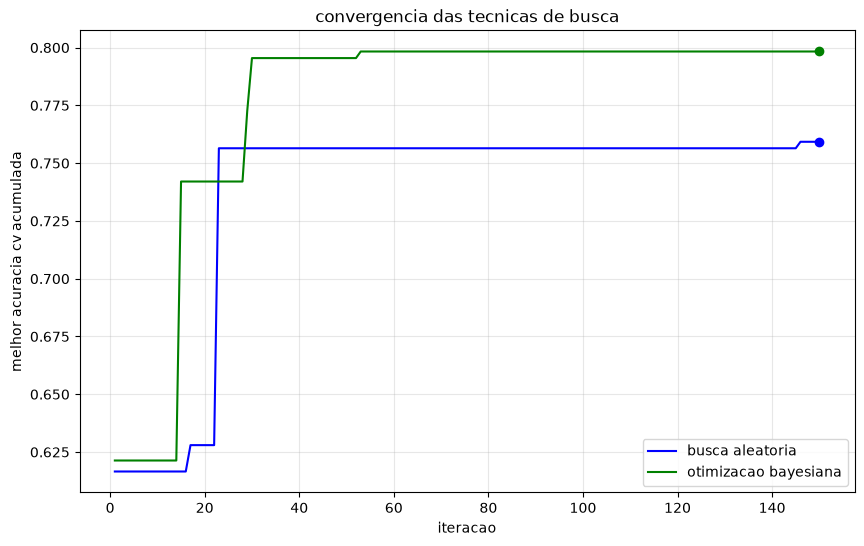

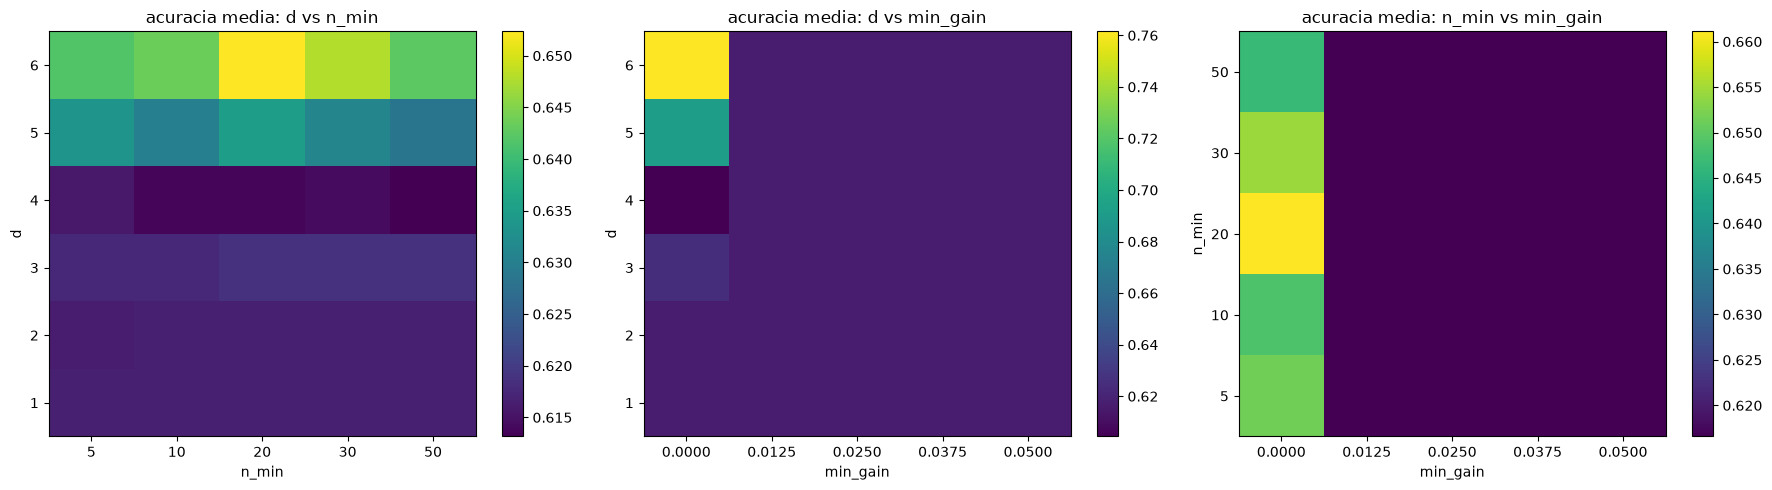

In [59]:
gerar_grafico_convergencia(hist_rand, hist_bay)
gerar_heatmaps(res_agregados)

In [60]:
print("\navaliacao final no conjunto de teste:\n")
configs = [config_grade, config_rand, config_bay]
res_cv = [acc_grade, acc_rand, acc_bay]
tempos = [t_grade, t_rand, t_bay]
n_modelos = [n_mod_grade, n_mod_rand, n_mod_bay]

avaliacao_final_teste(x_tr, y_tr, x_te, y_te, configs, res_cv, tempos, n_modelos)


avaliacao final no conjunto de teste:

estrategia   | tripla (d, n_min, min_gain)    | acc cv   | acc teste  | ajustes  | tempo (s) 
------------------------------------------------------------------------------------------
grade        | (6, 20, 0.0000)                | 0.7955   | 0.7884     | 600      | 1.1444
aleatoria    | (6, 10, 0.0019)                | 0.7593   | 0.7751     | 600      | 0.9392
bayesiana    | (6, 20, 0.0025)                | 0.7983   | 0.6281     | 600      | 1.5673

matrizes de confusao no teste:

--- grade ---
             | predito 0 | predito 1
------------------------------------
verdadeiro 0 |       171 |        53
verdadeiro 1 |        42 |       183

--- aleatoria ---
             | predito 0 | predito 1
------------------------------------
verdadeiro 0 |       194 |        30
verdadeiro 1 |        71 |       154

--- bayesiana ---
             | predito 0 | predito 1
------------------------------------
verdadeiro 0 |       113 |       111
verdadeiro 1 